In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Embedding
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import requests
import pickle

In [5]:
url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
request = requests.get(url)

In [6]:
request

<Response [200]>

In [7]:
with open('Shakespear.txt', 'w', encoding='utf-8') as f:
    f.write(request.text)

In [8]:

with open('Shakespear.txt', 'r', encoding='utf-8') as f:
    text = f.read()

In [9]:
print("length of text : " , len(text))

length of text :  1115394


In [10]:

chars = sorted(list(set(text)))
vocab_size = len(chars)
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

print(f"Vocabulary size: {vocab_size}")
print(f"Characters: {''.join(chars[:50])}...")

Vocabulary size: 65
Characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijk...


In [11]:
encoded_text = [char_to_idx[ch] for ch in text]


seq_length = 100
X, y = [], []

for i in range(len(encoded_text) - seq_length):
    X.append(encoded_text[i:i + seq_length])
    y.append(encoded_text[i + seq_length])

X = np.array(X)
y = np.array(y)

print(f"Total sequences: {len(X):,}")


split_idx = int(0.9 * len(X))
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

print(f"Training sequences: {len(X_train):,}")
print(f"Validation sequences: {len(X_val):,}")

Total sequences: 1,115,294
Training sequences: 1,003,764
Validation sequences: 111,530


In [12]:
model = Sequential([
    Embedding(vocab_size, 128, input_length=seq_length),
    LSTM(256, return_sequences=True),
    Dropout(0.2),
    LSTM(256),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dense(vocab_size, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [13]:
dummy_input = np.zeros((1, seq_length))
_ = model(dummy_input)

In [14]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

In [15]:
model.summary()

total_params = model.count_params()
print(f'\nTotal parameters: {total_params:,}')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (1, 100, 128)          │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (1, 100, 256)          │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (1, 100, 256)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (1, 256)               │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (1, 256)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 128)               │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 65)                │         8,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 969,153 (3.70 MB)

 Trainable params: 969,153 (3.70 MB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 969,153


In [16]:
checkpoint = ModelCheckpoint('best_shakespeare_model.keras',
                           monitor='val_loss',
                           save_best_only=True,
                           verbose=1)

early_stop = EarlyStopping(monitor='val_loss',
                          patience=3,
                          restore_best_weights=True,
                          verbose=1)

lr_reduce = ReduceLROnPlateau(monitor='val_loss',
                             factor=0.7,
                             patience=2,
                             min_lr=1e-7,
                             verbose=1)



In [17]:
epochs = 50
batch = 128

history = model.fit(X_train, y_train, epochs=epochs, validation_data=(X_val, y_val), batch_size=batch , callbacks=[checkpoint, early_stop, lr_reduce], verbose=1)

Epoch 1/50
7842/7842 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.3777 - loss: 2.1821
Epoch 1: val_loss improved from inf to 1.67406, saving model to best_shakespeare_model.keras
7842/7842 ━━━━━━━━━━━━━━━━━━━━ 584s 73ms/step - accuracy: 0.3777 - loss: 2.1821 - val_accuracy: 0.5062 - val_loss: 1.6741 - learning_rate: 0.0010
Epoch 2/50
7842/7842 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5410 - loss: 1.5170
Epoch 2: val_loss improved from 1.67406 to 1.58455, saving model to best_shakespeare_model.keras
7842/7842 ━━━━━━━━━━━━━━━━━━━━ 562s 72ms/step - accuracy: 0.5410 - loss: 1.5170 - val_accuracy: 0.5311 - val_loss: 1.5845 - learning_rate: 0.0010
Epoch 3/50
7842/7842 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5628 - loss: 1.4298
Epoch 3: val_loss improved from 1.58455 to 1.55254, saving model to best_shakespeare_model.keras
7842/7842 ━━━━━━━━━━━━━━━━━━━━ 563s 72ms/step - accuracy: 0.5628 - loss: 1.4297 - val_accuracy: 0.5429 - val_loss: 1.5525 - learning_rate: 0.0010
Epoch 4/

In [18]:
tokenizer_data = {
    'char_to_idx': char_to_idx,
    'idx_to_char': idx_to_char,
    'vocab_size': vocab_size

}

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer_data, f)

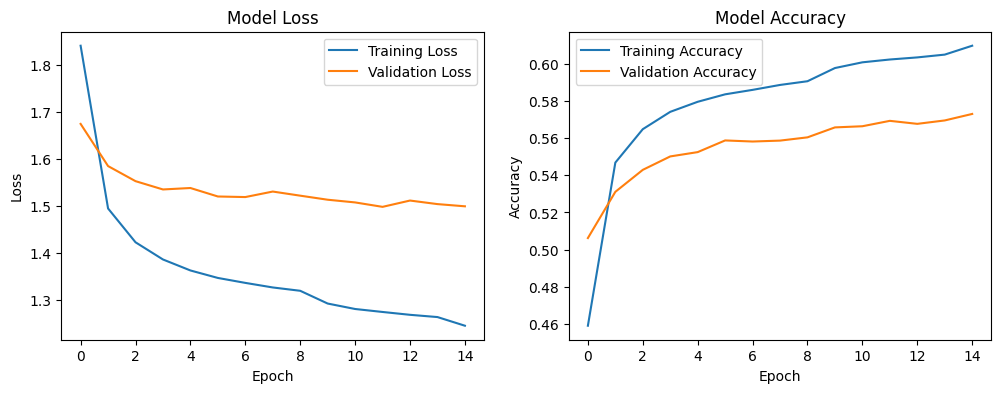

In [19]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


In [22]:
def generate_text(model, seed_text, length=500, temperature=0.7):
    result = list(seed_text)
    input_seq = [char_to_idx[ch] for ch in seed_text[-seq_length:]]

    for _ in range(length):
        x = np.array([input_seq[-seq_length:]])
        preds = model.predict(x, verbose=0)[0]
        preds = np.log(preds + 1e-8) / temperature
        preds = np.exp(preds) / np.sum(np.exp(preds))
        next_idx = np.random.choice(len(preds), p=preds)
        result.append(idx_to_char[next_idx])
        input_seq.append(next_idx)

    return ''.join(result)

# Generate sample text
seed = text[:seq_length]
print("Generated Text:\n")
print(generate_text(model, seed, length=500, temperature=0.5))

Generated Text:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You have walk'd to prove for this is the rest,
And come to be so all away to come:
I must be the princely traitor, while he comes
On the return of my field and twan a
poor brother sweet to the commonward of
the heavens and thy sake. He comes to see
The man with the man shall be planted in the power.

WARWICK:
Why, then my lord of the present state of strength
Of a place of blood of the messenger;
And we cannot hear me to the prince of them.

Third Servingman:
Then she was not to suppose to live on.
